In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import scipy.stats as stats

sns.set_theme(color_codes=True)

In [2]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')


In [3]:
print(df.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [4]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

In [5]:
print(df.isnull().sum())

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64




*  The 'Blood Pressure' column is a string like '120/80'.
*   We need to split it into two numerical features: Systolic and Diastolic.





In [6]:

df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

df = df.drop(columns=['Blood Pressure'])

In [7]:
cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
for column in cols:
    print(f"Column '{column}': {df[column].unique()}")

Column 'Gender': ['Male' 'Female']
Column 'Occupation': ['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']
Column 'BMI Category': ['Overweight' 'Normal' 'Obese' 'Normal Weight']
Column 'Sleep Disorder': ['None' 'Sleep Apnea' 'Insomnia']


converting unique values into numerics

In [8]:
le = LabelEncoder()

for col in cols:
    df[col] = le.fit_transform(df[col])

display(df.head())

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,1,27,9,6.1,6,42,6,3,77,4200,1,126,83
1,2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,3,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,4,1,28,6,5.9,4,30,8,2,85,3000,2,140,90
4,5,1,28,6,5.9,4,30,8,2,85,3000,2,140,90


Histplots

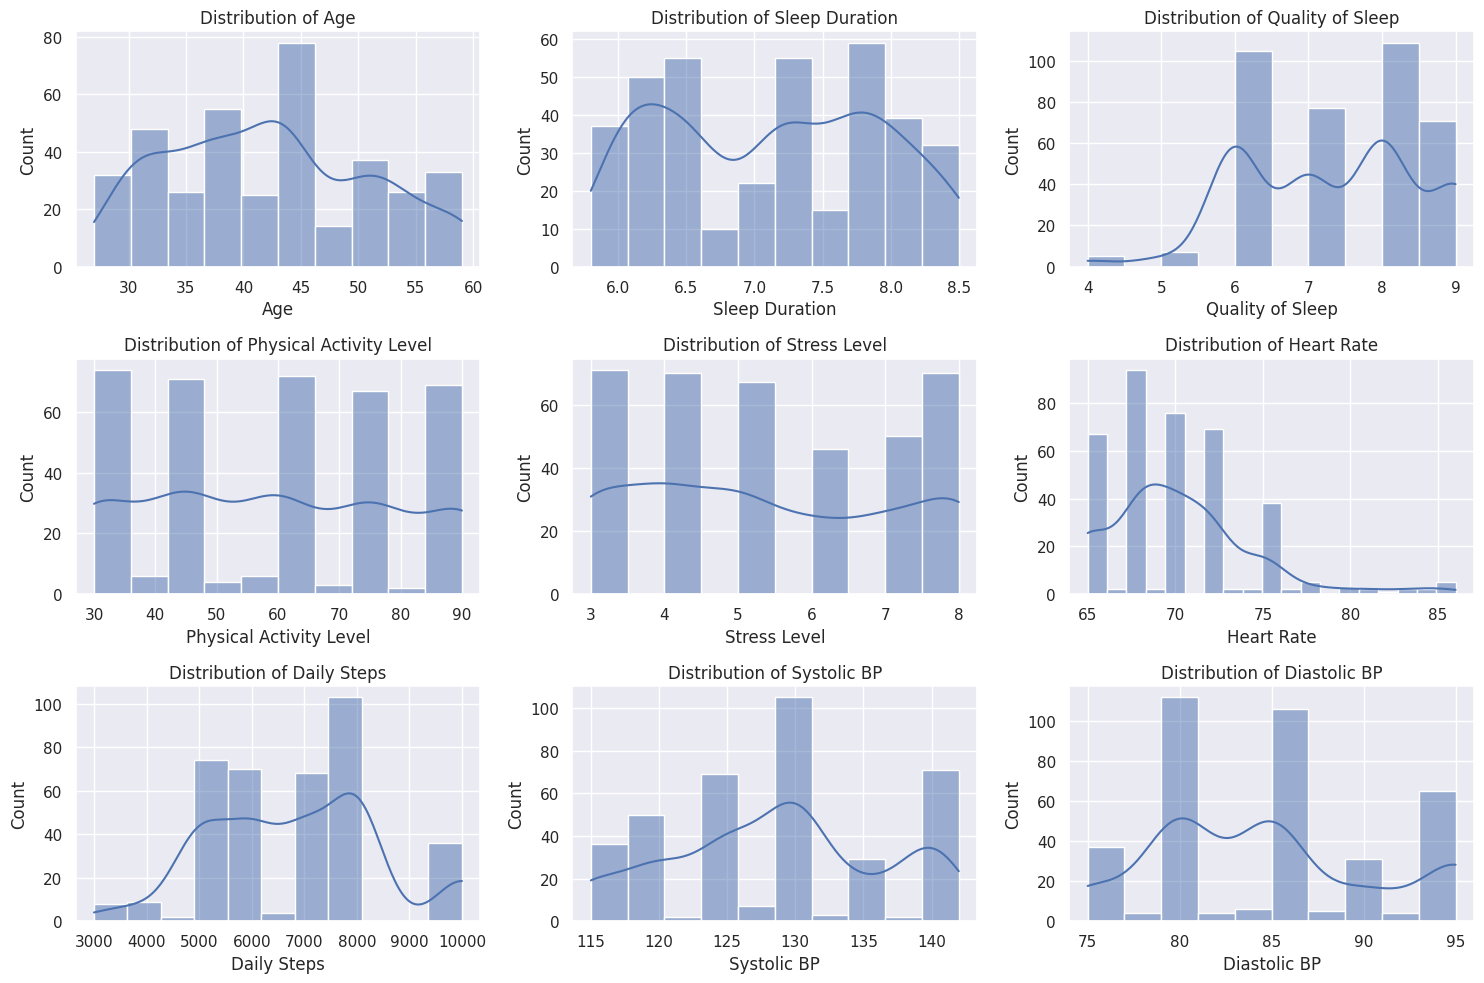

In [9]:
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()



Countplots


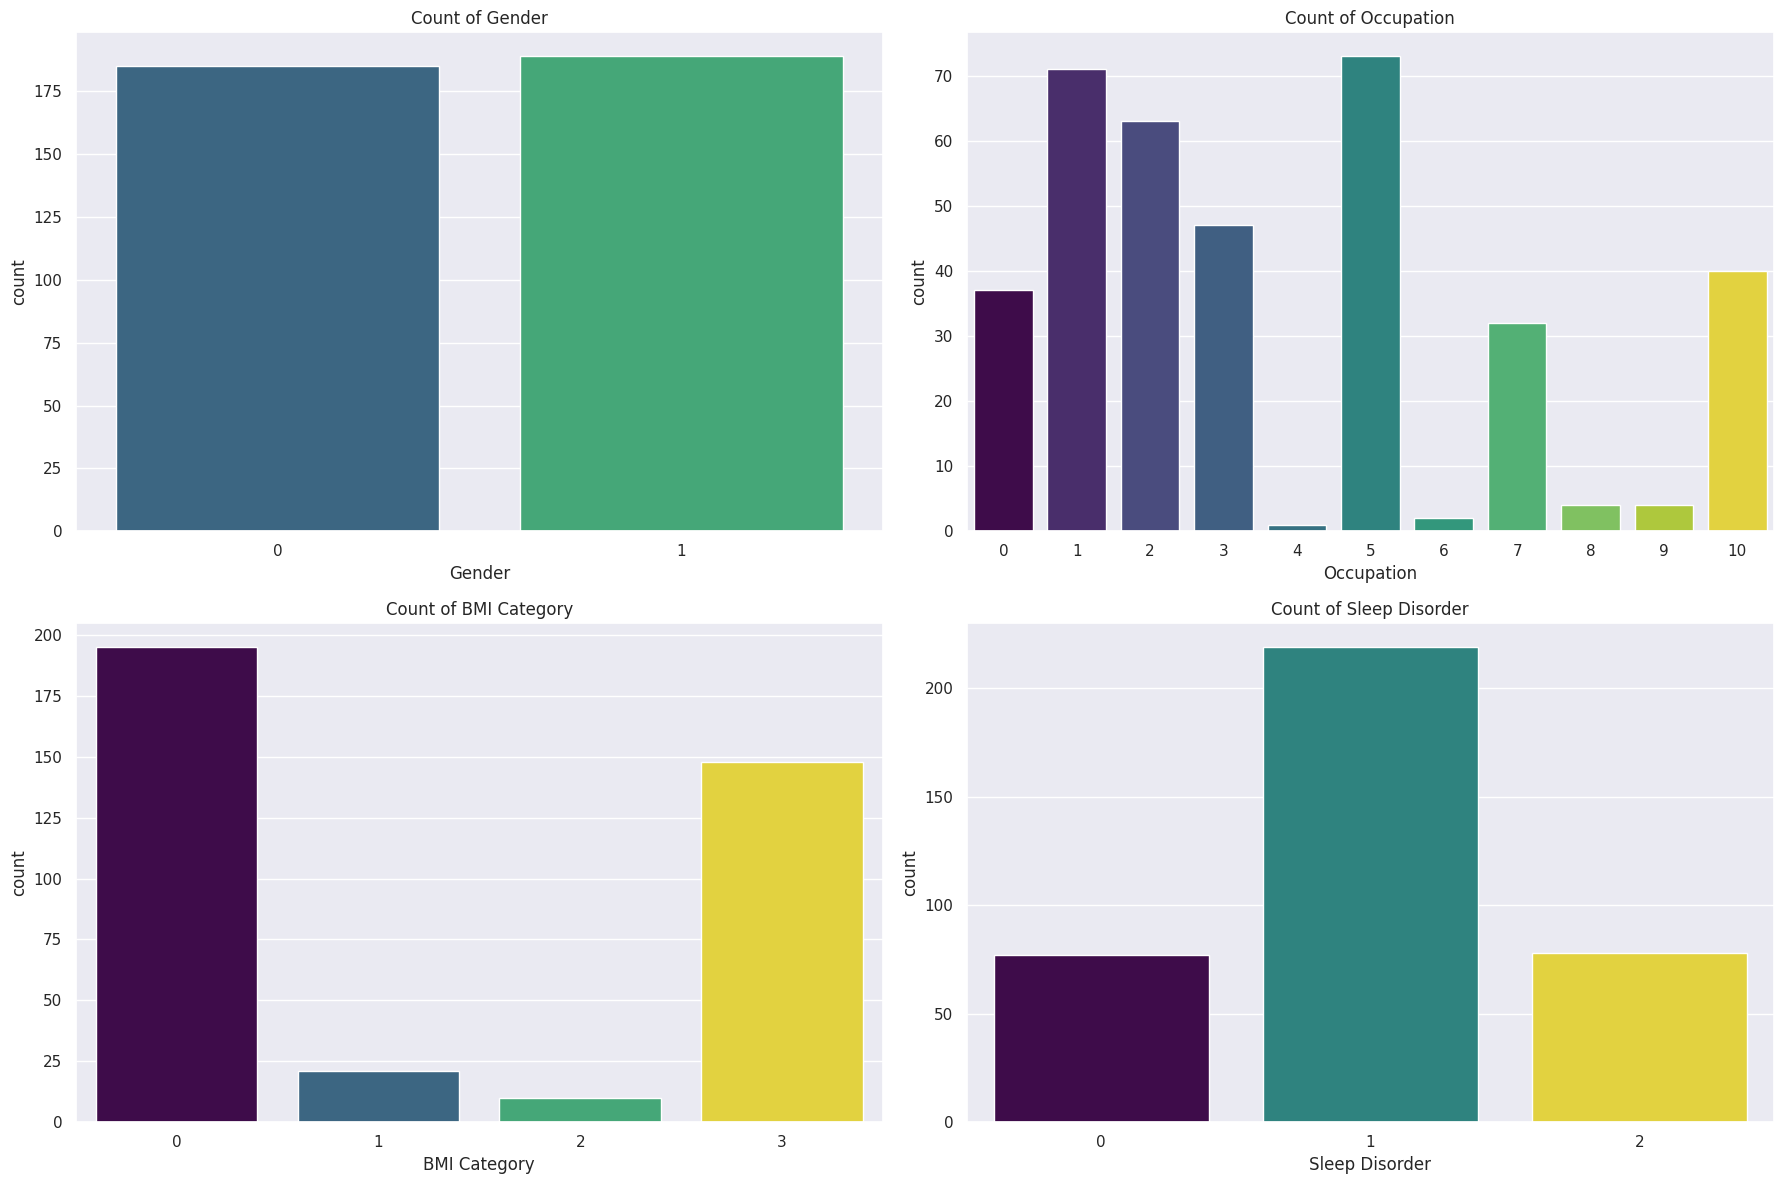

In [10]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

Boxplots


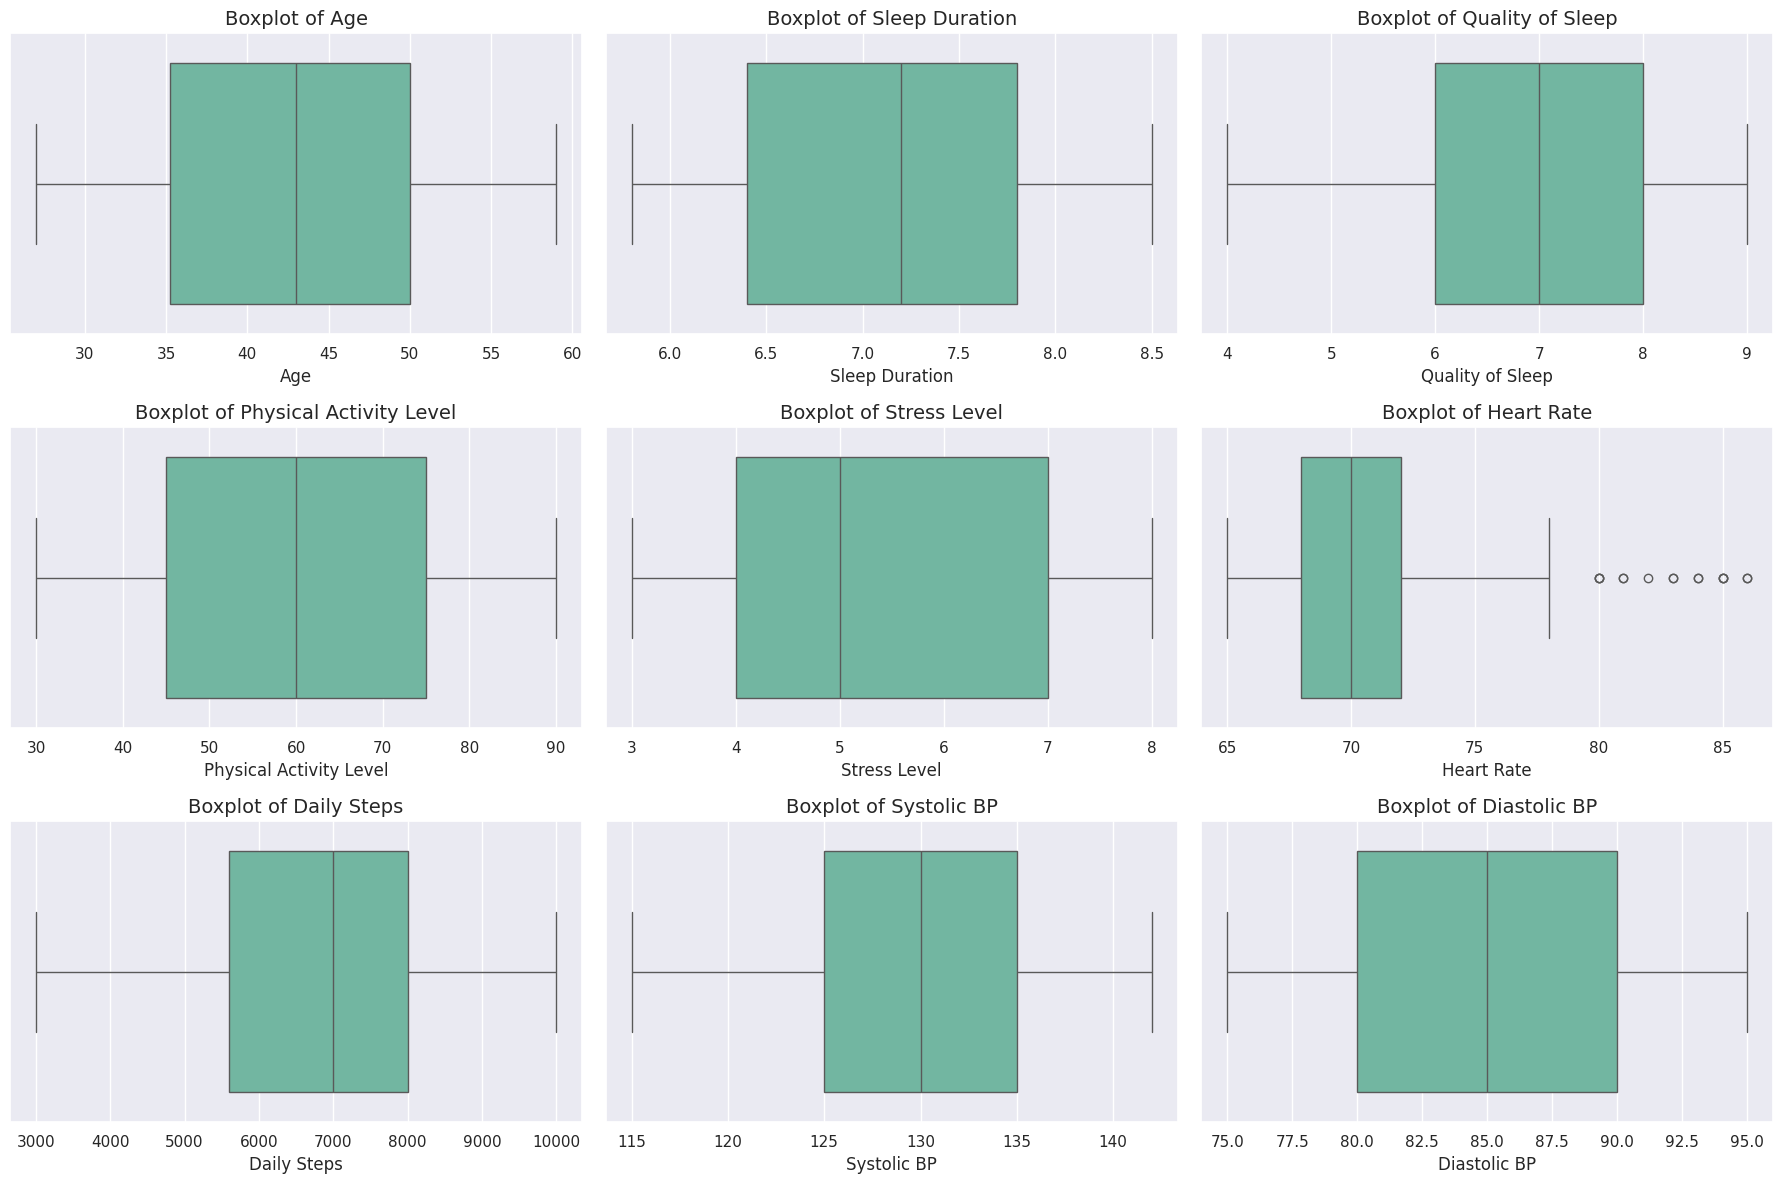

In [11]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[col], color=sns.color_palette('Set2')[0])
    plt.title(f'Boxplot of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)

plt.tight_layout()
plt.show()

In [12]:

z = np.abs(stats.zscore(df.drop(columns=['Person ID'])))
data_clean = df[(z < 3).all(axis=1)]

print(f"Shape before outlier removal: {df.shape}")
print(f"Shape after outlier removal: {data_clean.shape}")

Shape before outlier removal: (374, 14)
Shape after outlier removal: (365, 14)


<Axes: >

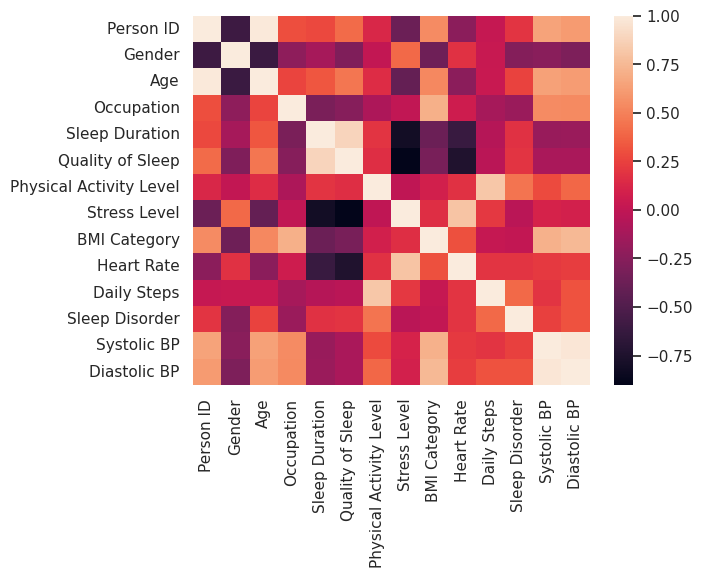

In [13]:
sns.heatmap(data_clean.corr(), fmt='.2g')

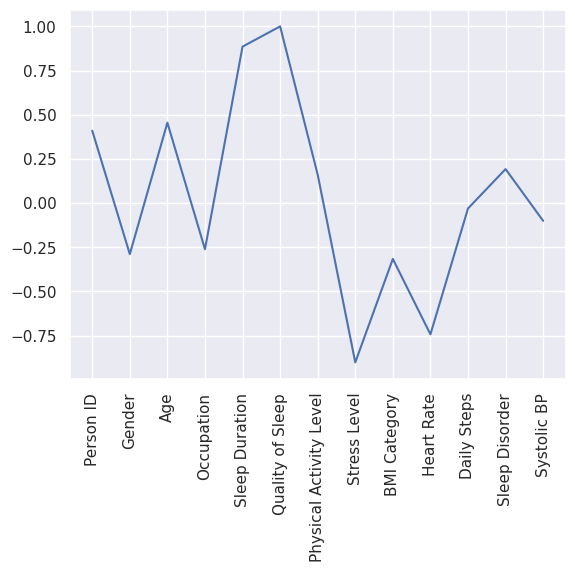

In [14]:
corr = data_clean[data_clean.columns[0:]].corr()['Quality of Sleep'][:-1]
plt.plot(corr)
plt.xticks(rotation=90)
plt.show()

In [15]:
X = df.drop("Quality of Sleep",axis=1)
y = df["Quality of Sleep"]

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=0)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames to maintain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Random Forest Accuracy: 98.67%
Logistic Regression Accuracy: 94.67%
Support Vector Machine Accuracy: 97.33%
K-Nearest Neighbors Accuracy: 90.67%
Decision Tree Accuracy: 97.33%
Gradient Boosting Accuracy: 98.67%
Naive Bayes Accuracy: 80.00%


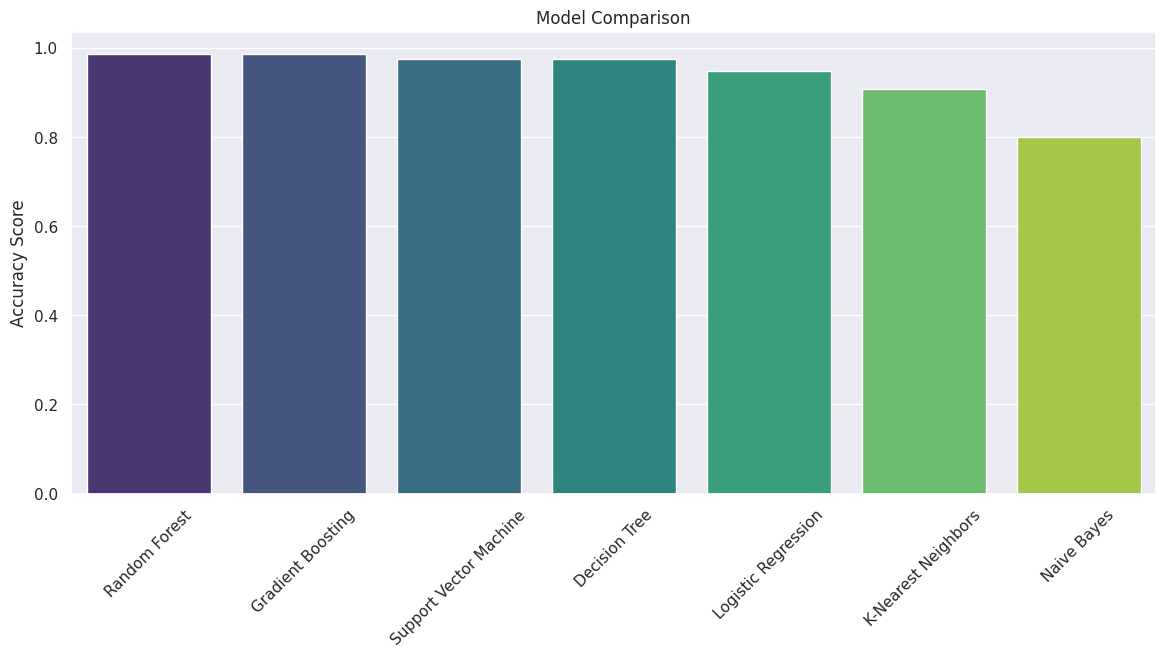

In [18]:
from sklearn.naive_bayes import GaussianNB


models = {
    "Random Forest": RandomForestClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=5000),
    "Support Vector Machine": SVC(random_state=0),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
    "Naive Bayes": GaussianNB()
}

results = {}
for name, model in models.items():
    # Use scaled data for Logistic Regression and SVM
    if name in ["Logistic Regression", "Support Vector Machine"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy*100:.2f}%")


plt.figure(figsize=(14, 6))

sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
sns.barplot(x=list(sorted_results.keys()), y=list(sorted_results.values()), hue=list(sorted_results.keys()), palette='viridis', legend=False)

plt.xticks(rotation=45)
plt.ylabel('Accuracy Score')
plt.title('Model Comparison')
plt.show()

In [19]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Prepare model_eval_list to map models to their appropriate test data
model_eval_list = [
    ("Random Forest", models["Random Forest"], X_test),
    ("Logistic Regression", models["Logistic Regression"], X_test_scaled),
    ("Support Vector Machine", models["Support Vector Machine"], X_test_scaled),
    ("K-Nearest Neighbors", models["K-Nearest Neighbors"], X_test),
    ("Decision Tree", models["Decision Tree"], X_test),
    ("Gradient Boosting", models["Gradient Boosting"], X_test),
    ("Naive Bayes", models["Naive Bayes"], X_test)
]

for name, model, x_data in model_eval_list:
    y_pred = model.predict(x_data)

    print(f"Metrics for {name}")
    print('F-1 Score : ', f1_score(y_test, y_pred, average='weighted', zero_division=1))
    print('Precision Score: ', precision_score(y_test, y_pred, average='weighted', zero_division=1))
    print('Recall Score : ', recall_score(y_test, y_pred, average='weighted', zero_division=1))
    print("-" * 50)

Metrics for Random Forest
F-1 Score :  0.9932121212121213
Precision Score:  1.0
Recall Score :  0.9866666666666667
--------------------------------------------------
Metrics for Logistic Regression
F-1 Score :  0.9529898989898992
Precision Score:  0.9758730158730159
Recall Score :  0.9466666666666667
--------------------------------------------------
Metrics for Support Vector Machine
F-1 Score :  0.979878787878788
Precision Score:  1.0
Recall Score :  0.9733333333333334
--------------------------------------------------
Metrics for K-Nearest Neighbors
F-1 Score :  0.9238518518518519
Precision Score:  0.9495424836601307
Recall Score :  0.9066666666666666
--------------------------------------------------
Metrics for Decision Tree
F-1 Score :  0.9798346742862872
Precision Score:  0.9873333333333333
Recall Score :  0.9733333333333334
--------------------------------------------------
Metrics for Gradient Boosting
F-1 Score :  0.9932121212121213
Precision Score:  1.0
Recall Score :  0.986

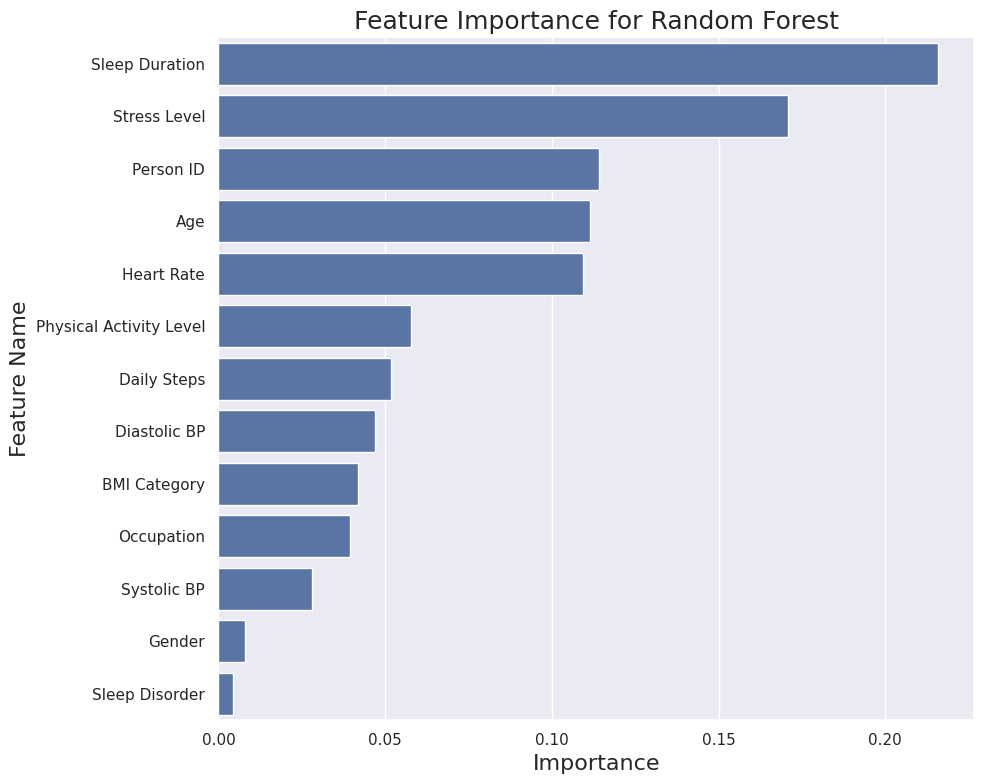

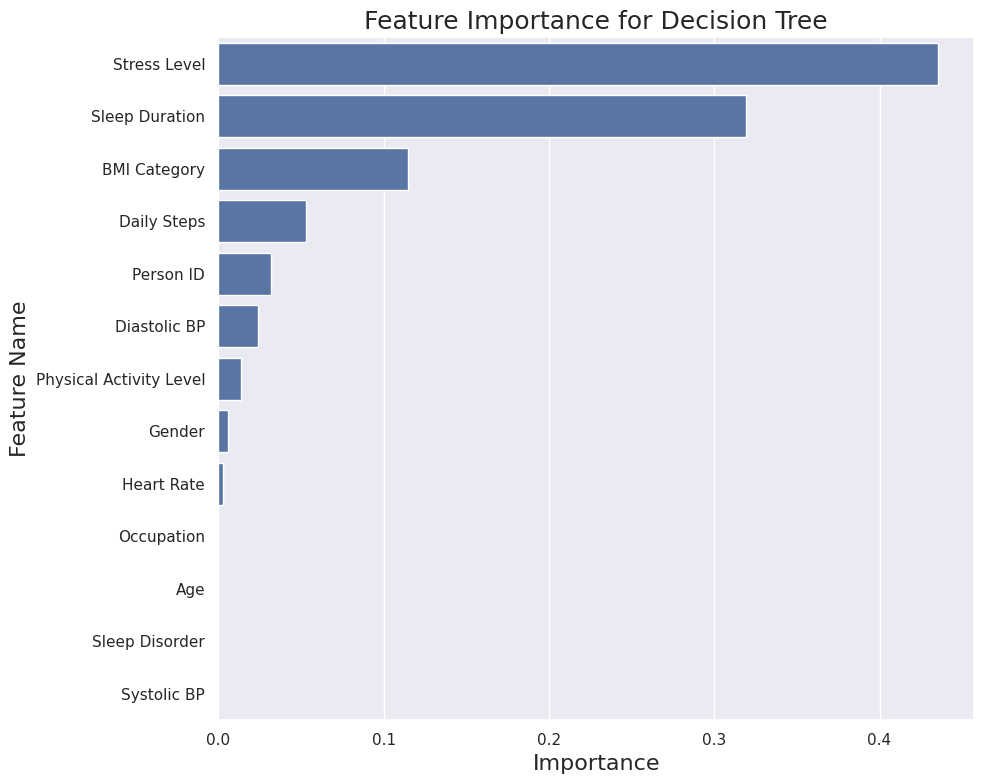

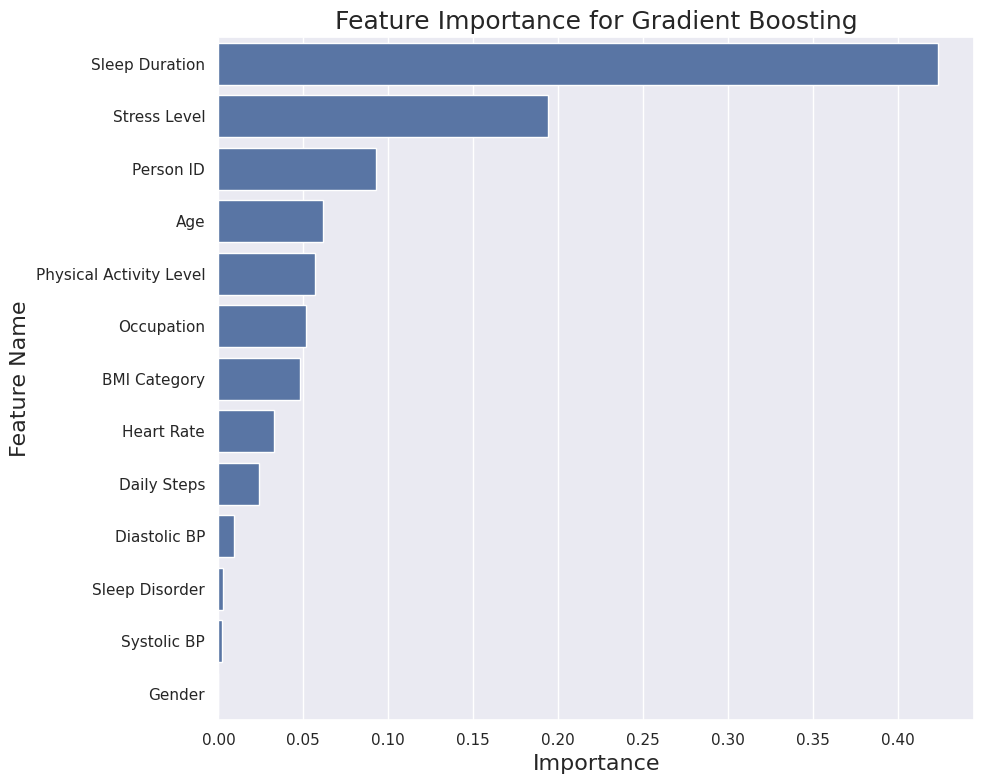

In [20]:
for name, model, x_data in model_eval_list:
  if hasattr(model, 'feature_importances_'):
    imp_df = pd.DataFrame({
      "Feature Name": X_train.columns,
        "Importance": model.feature_importances_
    })
    f1= imp_df.sort_values(by="Importance", ascending=False)
    plt.figure(figsize=(10,8))
    sns.barplot(data=f1, x='Importance', y='Feature Name')
    plt.title(f'Feature Importance for {name}', fontsize=18)
    plt.xlabel ('Importance', fontsize=16)
    plt.ylabel ('Feature Name', fontsize=16)

    plt.show()

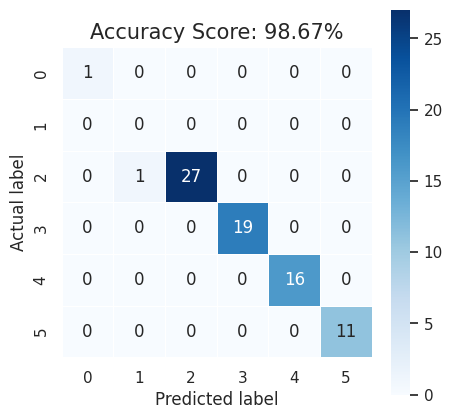

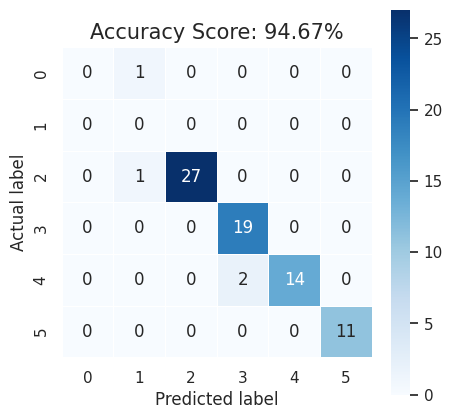

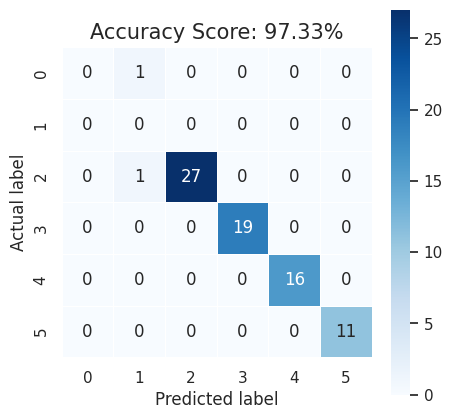

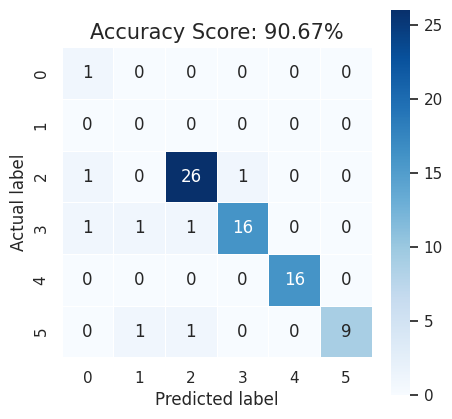

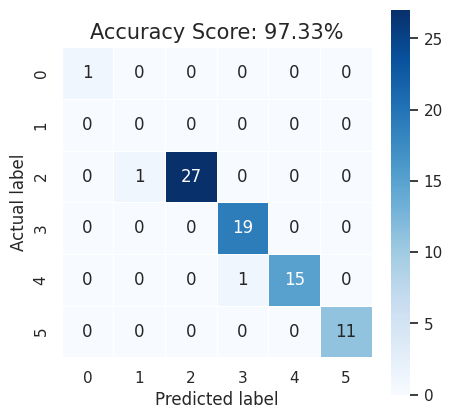

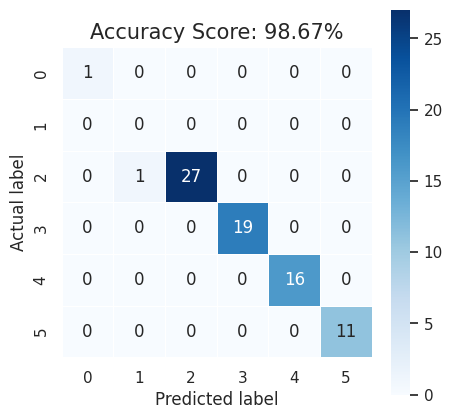

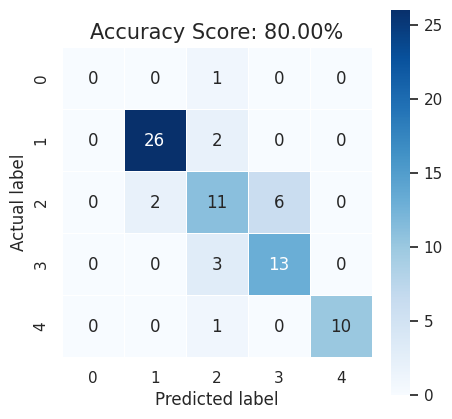

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

for name, model, x_data in model_eval_list:
    y_pred = model.predict(x_data)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,5))
    sns.heatmap(data=cm,linewidths=.5, annot=True,square = True,  cmap = 'Blues')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')

    all_sample_title = 'Accuracy Score: {0:.2f}%'.format(model.score(x_data, y_test)*100)
    plt.title(all_sample_title, size = 15)
    plt.show()